# Student Placement Package Prediction Using Linear Regression



## Introduction

This project focuses on predicting the placement package of a student based on different academic and personal factors.

This is a **regression problem** because the target variable, placement package, is a continuous numerical value. Unlike classification, where the output belongs to a category, regression is used to predict numerical values.

To solve this problem, I use **Linear Regression**, a supervised machine learning algorithm commonly used for regression problems.

The model learns the relationship between the input features and the placement package and uses this relationship to predict the expected package of a student.

### Problem Statement

Suppose a college has historical placement data. We know:

1. CGPA
2. Coding Skill
3. Aptitude Score
4. Communication Skill
5. Number of Projects
6. Number of Internships

Can we predict the placement package (LPA) offered to a student?

This is a Regression Problem because the output (package) is a continuous number.

## About Linear Regression

Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical target variable.

In this project, the target variable is the **placement package** of the student.

The model tries to find a linear relationship between the input features and the placement package. After training, this relationship is used to predict the expected package for new student data.

### Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Generating the Dataset

In [ ]:
print(np.random.randint(1,10,5))
#

[9 7 7 8 4]


In [ ]:
import numpy as np
np.random.seed(42)
print(np.random.randint(1,10,5))


[7 4 8 5 7]


## Generating the Whole Dataset

In [ ]:
np.random.seed(42)
n=300

### Generating the Features

In [ ]:
### CGPA
cgpa = np.random.uniform(5.5, 9.5,n)
### Coding Score
coding_score = np.random.randint(40,101,n)
### Aptitude Score
aptitude_score = np.random.randint(40,101,n)
### Communication Score
communication_score = np.random.randint(40,101,n)
### Number of Projects
number_of_projects = np.random.randint(0,6,n)
### Number of Internships
number_of_internships = np.random.randint(0,6,n)

## lets add some noise in the data

noise = np.random.normal(0,1,n)

### Generating the package

In [ ]:
package = (
    1 +
    0.25 * cgpa +
    0.015 * coding_score +
    0.01 * aptitude_score +
    0.02 * communication_score +
    0.3 * number_of_projects +
    0.4 * number_of_internships +
    noise
)

package = np.clip(package,2,10)
package = np.round(package,2)

## Creating the DataFrame

In [ ]:
data = pd.DataFrame({
    "cgpa":cgpa,
    "coding_score":coding_score,
    "aptitude_score":aptitude_score,
    "communication_score":communication_score,
    "number_of_projects":number_of_projects,
    "number_of_internships":number_of_internships,
    "package":package
})

In [ ]:
data.head(10)

,cgpa,coding_score,aptitude_score,communication_score,number_of_projects,number_of_internships,package
0,6.772446,87,85,64,5,0,7.82
1,8.965755,99,43,95,0,0,7.12
2,9.473348,57,99,42,5,4,8.10
3,8.509711,79,96,47,3,4,9.77
4,5.861927,74,84,83,2,2,7.68
5,6.654742,80,59,72,2,5,8.21
6,5.936439,68,56,81,5,3,7.95
7,8.102047,91,94,91,1,0,7.59
8,8.560763,68,46,74,4,4,9.31
9,9.202699,77,43,45,4,5,8.86


### Explore the Data

In [ ]:
data.describe()

,cgpa,coding_score,aptitude_score,communication_score,number_of_projects,number_of_internships,package
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,7.452748,69.896667,71.416667,70.396667,2.516667,2.493333,7.683667
std,1.083017,17.017579,17.831328,17.907585,1.698826,1.700862,1.363725
min,5.501330,40.000000,40.000000,40.000000,0.000000,0.000000,3.580000
25%,6.515515,56.000000,57.000000,55.000000,1.000000,1.000000,6.722500
50%,7.499558,70.000000,71.000000,70.500000,3.000000,2.000000,7.730000
75%,8.290345,84.000000,88.000000,86.000000,4.000000,4.000000,8.732500
max,9.481922,100.000000,100.000000,100.000000,5.000000,5.000000,10.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cgpa                   300 non-null    float64
 1   coding_score           300 non-null    int64  
 2   aptitude_score         300 non-null    int64  
 3   communication_score    300 non-null    int64  
 4   number_of_projects     300 non-null    int64  
 5   number_of_internships  300 non-null    int64  
 6   package                300 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 16.5 KB


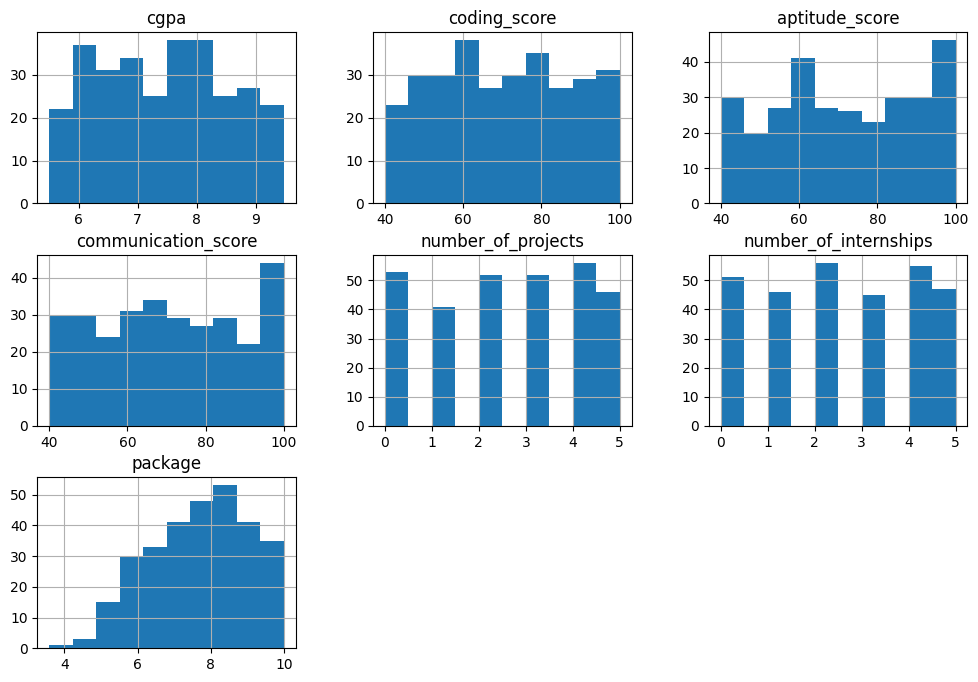

In [ ]:
### Lets visualize this Data
data.hist(figsize=(12,8))
plt.show()

### Selecting the features

In [ ]:
X = data.drop("package",axis=1)
y = data["package"]

### Splitting the data into the training and testing set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## lets train the model

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

## Prediction

In [ ]:
predictions = model.predict(X_test)
result = pd.DataFrame({
    "Actual":y_test,
    "Predicted":predictions
})
result.head(10)

,Actual,Predicted
203,6.50,8.018554
266,10.00,9.975068
152,7.98,8.398051
9,8.86,8.788464
233,8.15,7.160744
226,9.21,8.631702
196,8.42,7.062161
109,4.96,6.765819
5,8.21,8.249841
175,8.28,5.427639


## Evaluate the Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE", mean_absolute_error(y_test,predictions))
print("MSE", mean_squared_error(y_test,predictions))
print("R2 Score", r2_score(y_test, predictions))

MAE 0.8127938651800959
MSE 1.1008801276804836
R2 Score 0.44770818608561935


# Lets test the Model using the New student entry

In [ ]:
new_student = pd.DataFrame({
    "cgpa":[8.6],
    "coding_score":[90],
    "aptitude_score":[92],
    "communication_score":[80],
    "number_of_projects":[4],
    "number_of_internships":[2],
})
predicted_package = model.predict(new_student)
print("Predicted package(LPA)", round(predicted_package[0],2))


Predicted package(LPA) 9.1
Predicted package(LPA) 9.1


## Conclusion

In this project, I built a Linear Regression model to predict the placement package of a student.

This project helped me understand the basic workflow of a machine learning regression problem, including data preprocessing, exploratory data analysis, model training, prediction, and model evaluation.

This is a beginner-level project that demonstrates how Linear Regression can be applied to a real-world student placement package prediction problem.